# Julia's fractal generator algorithm

__Julia sets are sets of points in the complex plane that form intricate geometric patterns. They are generated by the recursive iteration of a function, typically $f(z) = z^2 + c$.__

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import time as tm

### Principal Algorithm

In [32]:
def recursiveJulia(z, c, iteration, max_iter):
    
    if abs(z) > 2:
        return iteration
    
    if iteration >= max_iter:
        return max_iter
    
    new_z = z * z + c
    
    return recursiveJulia(new_z, c, iteration + 1, max_iter)

# test
recursiveJulia(0+0j, -0.7+0.27015j, 0, 10)

10

### Comparision times with diferents inputs (max_iter)

As we can se in the next cell of code, the algorithm "recursiveJulia" doesn't take a lot of time despite the size of the input (max_iter).

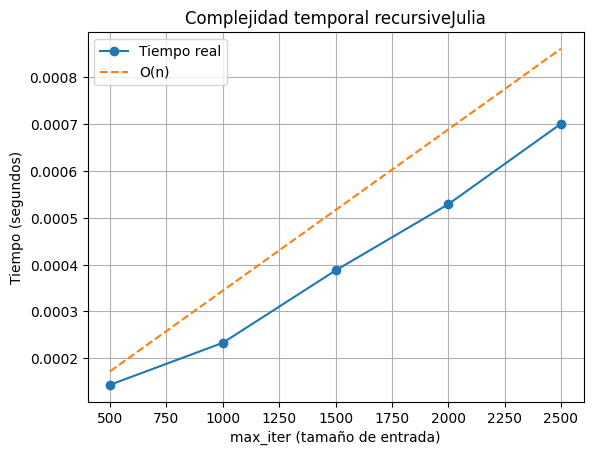

In [ ]:
max_iters = np.arange(500, 2700, 500)
times = []

for maxIter in max_iters:
    t0 = tm.perf_counter()
    recursiveJulia(0+0j, 0+0j, 0, int(maxIter))
    t1 = tm.perf_counter()
    
    times.append(t1 - t0)

# Curva real
plt.plot(max_iters, times, marker="o", label="Tiempo real")

# Curva teórica O(n)
ratios = [t/n for t, n in zip(times, max_iters)]
c = max(ratios) * 1.2

teorico = [c * x for x in max_iters]
plt.plot(max_iters, teorico, linestyle="--", label="O(n)")

plt.xlabel("max_iter (tamaño de entrada)")
plt.ylabel("Tiempo (segundos)")
plt.title("Complejidad temporal recursiveJulia")
plt.legend()
plt.grid()
plt.show()

### Results generator functions

Function that generates the list of results that we need to plot a set of Julia.

In [34]:
def resultsGenerator(width, height, realC, imagC, maxIter):
    x = np.linspace(-2, 2, width)
    y = np.linspace(-2, 2, height)

    results = np.zeros((height, width))
    c = complex(realC, imagC)

    t0 = tm.perf_counter()
    for i in range(height):
        for j in range(width):
            
            real = x[j]
            imag = y[i]
            
            z = complex(real, imag)
            
            results[i, j] = recursiveJulia(z, c, 0, maxIter)
    t1 = tm.perf_counter()
    finalTime = t1 - t0
    
    return results, finalTime

### 2D drawing example

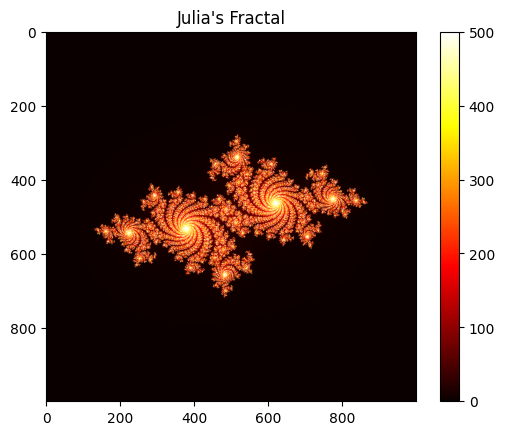

4.876693499973044


In [35]:
results, finalTime = resultsGenerator(1000, 1000, -0.7, 0.27015, 500)
plt.imshow(results, cmap='hot')
plt.colorbar()
plt.title("Julia's Fractal")
plt.show()
print(finalTime)

### Comparision time with different measures (resultsGenerator)

times recorded: [4.897333799977787, 20.872552999993786, 127.9930575999897, 370.03529949998483, 689.974704900058]
Measures used: [1000, 2000, 3000, 4000, 5000]


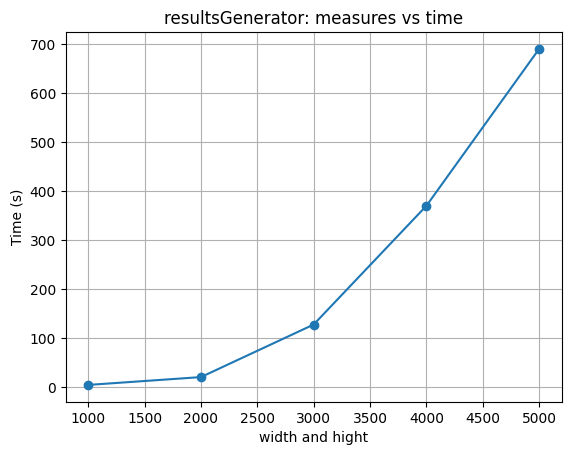

In [36]:
measures = [1000, 2000, 3000, 4000, 5000]
timesM = []
resultsArray = []

for measure in measures:
    resultsM, finalTimeM = resultsGenerator(measure, measure, -0.7, 0.27015, 500)
    resultsArray.append(resultsM)
    timesM.append(finalTimeM)
    
print(f"times recorded: {timesM}\nMeasures used: {measures}")
plt.plot(measures, timesM, marker="o")
plt.title("resultsGenerator: measures vs time")
plt.xlabel("width and hight")
plt.ylabel("Time (s)")
plt.grid()
plt.show()

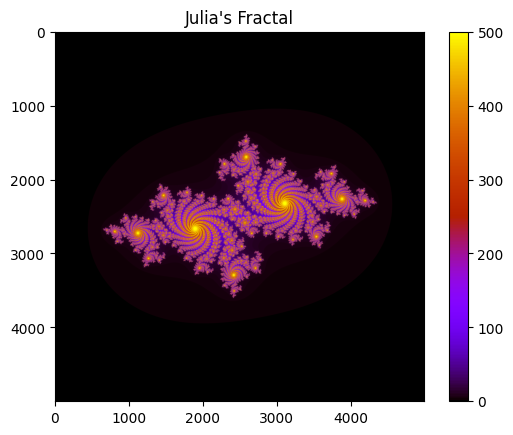

In [37]:
plt.imshow(resultsArray[-1], cmap='gnuplot')
plt.colorbar()
plt.title("Julia's Fractal")
plt.show()